In [1]:
#
# KT AICE Associate 자격인증 실전 연습문제: House Prices Prediction
#
# 이 연습문제는 'House Prices - Advanced Regression Techniques' 데이터셋을 사용하여
# 데이터 분석, 전처리, 머신러닝 및 딥러닝 회귀 모델 학습 및 평가 능력을 평가합니다.
#
# [유의사항]
# • 각 문항의 답안코드는 반드시 '# 여기에 답안코드를 작성하세요'로 표시된 cell에 작성해야 합니다.
# • 문제에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.
# • 문제에서 명시적으로 요구하는 함수나 방법을 사용해야 합니다.
#
# [데이터 컬럼 설명 (데이터 파일명: train.csv)]
# SalePrice : 판매 가격 ($) - Target Variable
# GrLivArea : 지상 생활 공간 면적 (평방 피트)
# OverallQual : 전체 재료 및 마감 품질 등급 (1-10)
# YearBuilt : 건축 연도
# 1층, 2층 면적, 차고 크기 등 다양한 주택 관련 특성이 포함되어 있습니다.
#


In [2]:
# --- 문제 1. 라이브러리 불러오기 ---
# Pandas를 pd로, Numpy를 np로 불러오고, 시각화 라이브러리인 Matplotlib의 pyplot을 plt로 불러오세요.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# --- 문제 2. 데이터 파일 읽어오기 및 기본 정보 확인 ---
# 데이터 파일 'train.csv'를 읽어 데이터프레임 변수 df에 할당하고,
# 데이터프레임의 전체 행, 열 개수 및 각 컬럼의 데이터 타입 정보를 확인하는 코드를 작성하세요.
# • 데이터프레임 변수명: df
# • 데이터 파일명: train.csv

In [5]:
df=pd.read_csv("house_price.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
# --- 문제 3. 타겟 변수 'SalePrice'의 분포 시각화 및 변환 ---
# 1. 'SalePrice' 컬럼의 분포를 Seaborn의 distplot을 사용하여 시각화하세요. (kde=True 설정)
# 2. 'SalePrice'의 분포가 오른쪽으로 꼬리가 긴 형태(right-skewed)임을 확인하고,
#    정규 분포에 가깝게 만들기 위해 Numpy의 log1p 함수를 사용하여 로그 변환을 수행하고,
#    그 결과를 'y_log' 변수에 저장하세요.
# • y_log = log(1 + SalePrice)

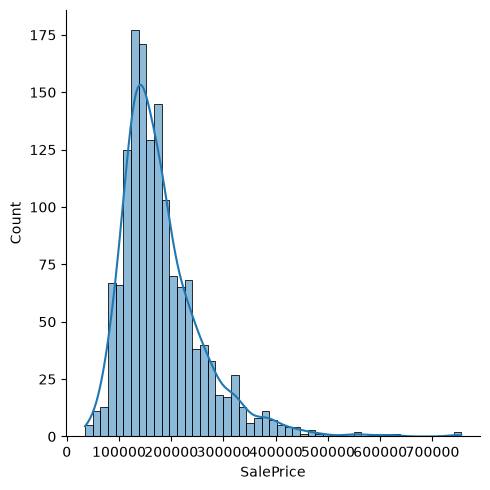

In [7]:
import seaborn as sns
sns.displot(df['SalePrice'], kde=True)
y_log = np.log1p(df['SalePrice'])

In [8]:
# --- 문제 4. 범주형 컬럼의 고유값 비율 확인 ---
# 'object' 타입의 컬럼 중 'MSZoning' 컬럼의 각 고유값(범주)별 데이터가 차지하는 비율을 확인하고,
# 그 결과를 '답안04_1' 변수에 저장하세요. (Series 형태로 저장)
# 이 정보를 바탕으로, 비율이 가장 높은 고유값을 '답안04_2' 변수에 문자열로 저장하세요.
# • 활용 함수: value_counts(normalize=True)

In [9]:
답안04_1 = df['MSZoning'].value_counts(normalize=True)
답안04_2 = 'RL'

In [10]:
# --- 문제 5. 'GarageType' 컬럼 결측치 처리 (최빈값) ---
# 'GarageType' 컬럼의 결측치(NaN)를 해당 컬럼의 최빈값(mode)으로 대체(impute)하는 코드를 작성하고,
# 그 결과를 df에 반영하세요.
# 처리 후, 'GarageType' 컬럼의 결측치 개수를 '답안05' 변수에 저장하세요.
# • 활용 함수: mode()

In [11]:
df['GarageType'].isnull().sum()

df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])

답안05 = 0

In [12]:
# --- 문제 6. 다수 결측치 컬럼 삭제 및 'LotFrontage' 중간값 처리 ---
# 1. 결측치가 전체 데이터의 50% 이상인 컬럼을 df에서 삭제하고, 그 결과를 df_temp에 저장하세요.
#    (Hint: 'Cabin' 컬럼 등이 해당될 수 있습니다.)
# 2. df_temp에서 'LotFrontage' 컬럼의 결측치를 해당 컬럼의 중앙값(median)으로 대체하고 df_temp에 반영하세요.
# 3. 'LotFrontage' 중간값 처리 후 df_temp에 남아있는 전체 결측치의 개수를 '답안06' 변수에 저장하세요.
# • 활용 함수: dropna(axis=1), median()

In [13]:
df.isnull().sum()
df_temp = df.dropna(axis=1, thresh=731)
df_temp.loc[:, 'LotFrontage'] = df_temp['LotFrontage'].fillna(df['LotFrontage'].median())
df_temp.isnull().sum().sum()

답안06 = 1210

In [14]:
# --- 문제 7. 특정 연속형 컬럼 간의 상관관계 시각화 (heatmap) ---
# 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF' 4개 컬럼 간의 상관관계를 확인하고자 합니다.
# 1. 위 4개 컬럼만을 추출하여 상관관계 행렬을 구하고 'corr_matrix' 변수에 저장하세요.
# 2. Seaborn의 heatmap을 사용하여 이 상관관계 행렬을 시각화하세요.
# 3. 'GrLivArea' 컬럼과 상관관계가 가장 높은 컬럼을 '답안07' 변수에 저장하세요.

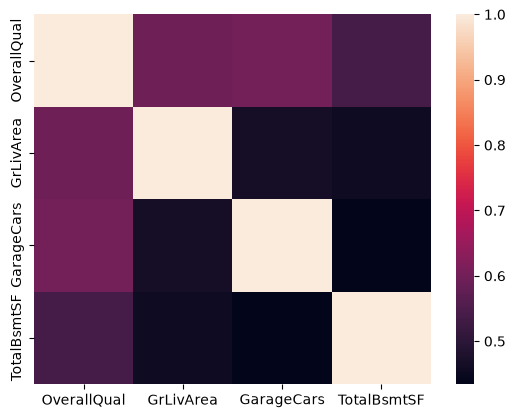

In [15]:
corr_matrix = df[['OverallQual','GrLivArea', 'GarageCars', 'TotalBsmtSF']].corr()
sns.heatmap( data=corr_matrix )
답안07 = 'OverallQual'

In [16]:
# --- 문제 8. 범주형 컬럼 변환 (Label Encoding) ---
# 일부 순서형(Ordinal) 범주형 피처를 수치형으로 변환하려고 합니다.
# 'KitchenQual' 컬럼에 대해 Scikit-learn의 LabelEncoder를 사용하여 인코딩을 수행하고 df_temp에 반영하세요.
# 1. LabelEncoder 객체를 생성하고 학습(fit) 및 변환(transform)을 수행하세요.
# 2. 변환 후 'KitchenQual' 컬럼의 고유값 개수를 '답안08' 변수에 저장하세요.
# • 활용 함수: LabelEncoder

from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()
df_temp.loc[:,'KitchenQual'] = le.fit_transform(df_temp['KitchenQual'])
답안08 = 4

In [18]:
# --- 문제 9. 나머지 범주형 컬럼 One-Hot 인코딩 및 최종 Feature/Label 분리 ---
# 1. df_temp에서 'object' 타입이 남아있는 모든 컬럼(Label Encoding을 하지 않은 나머지 범주형)에 대해
#    Pandas의 get_dummies()를 사용하여 원-핫 인코딩을 수행하고 그 결과를 df_final에 저장하세요.
# 2. Feature 데이터 X에 df_final을 할당하고, Label 데이터 y에 문제 3번에서 로그 변환한 y_log를 할당하세요.

In [19]:
df_final = pd.get_dummies(df_temp, dtype=int)
X = df_final
y = y_log

In [20]:
# --- 문제 10. 훈련/검증 데이터셋 분할 및 스케일링 (MinMaxScaler) ---
# 1. X와 y를 훈련데이터셋(X_train, y_train)과 검증데이터셋(X_valid, y_valid)으로 분리하세요.
#    (비율: 70:30, random_state: 100)
# 2. Scikit-learn의 MinMaxScaler를 사용하여 X_train과 X_valid 전체 컬럼에 대해 스케일링을 수행하세요.
# 3. 스케일링 후 X_train의 최소값(Min)을 '답안10' 변수에 저장하세요.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [21]:
X = X.fillna(X.mean())

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.3, random_state=100)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

답안10 = 0.0

In [23]:
# --- 문제 11. 머신러닝 회귀 모델 학습 (SVR) ---
# Support Vector Regressor (SVR) 모델을 만들고 학습을 진행하세요.
# 1. SVR 모델 객체를 'svr_model' 변수에 저장해 주세요.
# 2. kernel='rbf', C=10, epsilon=0.1로 설정하세요.
# 3. X_train과 y_train을 사용하여 모델을 학습시키세요.

from sklearn.svm import SVR

In [24]:
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [25]:
# --- 문제 12. SVR 모델 성능 평가 (Root Mean Squared Error) ---
# 위에서 학습한 SVR 모델의 성능을 평가하려고 합니다. (회귀 모델이므로 RMSE를 사용)
# 1. 학습된 'svr_model'로 X_valid에 대한 예측값(predict)을 구하여 'y_pred_svr' 변수에 저장하세요.
# 2. 예측값은 로그 변환된 값이므로, 지수 변환(np.expm1)을 통해 원래 스케일로 되돌리세요.
# 3. Scikit-learn의 mean_squared_error를 사용하여 RMSE(Root Mean Squared Error)를 구하고,
#    그 값을 'svr_rmse' 변수에 소수점 4째자리까지 반올림하여 저장하세요.

from sklearn.metrics import mean_squared_error


In [26]:
y_pred_svr = svr_model.predict(X_valid)
round(np.sqrt(mean_squared_error(np.expm1(y_valid), np.expm1(y_pred_svr))), 4)
svr_rmse = 27853.1115

In [27]:
# --- 문제 13. 딥러닝 회귀 모델 구현 및 학습 (TensorFlow/Keras) ---
# 주택 가격 예측을 위한 딥러닝 회귀 모델을 만들고 학습을 진행하세요. (로그 변환된 y_log를 예측)
# 1. Tensorflow/Keras의 Sequential API를 사용하세요.
# 2. 토폴로지: Input -> Dense(64, activation='relu') -> Dense(32, activation='relu') -> Dense(1, activation='linear')
# 3. optimizer는 'rmsprop', loss는 'mean_squared_error'(MSE), metrics는 'mean_absolute_error'(MAE)로 설정하여 모델 컴파일을 설정하세요.
# 4. EarlyStopping 콜백으로 val_loss가 10번 epoch 동안 향상되지 않을 때 훈련을 중지하도록 설정하고 estop_dl 변수에 저장하세요.
# 5. batch_size: 32, epoch: 200으로 모델을 학습하고 학습정보는 history_dl 변수에 저장해 주세요.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(100)

In [28]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=['mean_absolute_error'])
estop_dl = EarlyStopping( monitor='val_loss', patience=10, restore_best_weights=True)

history_dl = model.fit(X_train, y_train, batch_size=32, epochs=200, validation_data=(X_valid, y_valid), callbacks=[estop_dl] )

Epoch 1/200


/Users/todo/venv-sy-11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.5139 - mean_absolute_error: 4.0662 - val_loss: 0.3737 - val_mean_absolute_error: 0.4530
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3242 - mean_absolute_error: 0.4140 - val_loss: 0.1964 - val_mean_absolute_error: 0.3378
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2214 - mean_absolute_error: 0.3560 - val_loss: 0.1763 - val_mean_absolute_error: 0.3487
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1846 - mean_absolute_error: 0.3425 - val_loss: 0.0998 - val_mean_absolute_error: 0.2486
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1607 - mean_absolute_error: 0.3273 - val_loss: 0.2081 - val_mean_absolute_error: 0.4061
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.1366 - mean_absolute_error: 0.2994 - val_loss: 0.2777 - val_mean_absolute_error: 0.4825
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1282 - mean_absolute_error: 0.2891 - val_loss: 0.1658 

In [29]:
# --- 문제 14. 딥러닝 모델 성능 평가 및 시각화 (MAE) ---
# 학습된 딥러닝 모델의 학습 과정에서의 MAE(mean_absolute_error)와 검증 MAE(val_mean_absolute_error)를 그래프로 표시하세요.
# 1. 1개의 그래프에 학습 MAE와 검증 MAE 2가지를 모두 표시하세요.
# 2. 위 2가지 각각의 범례를 'MAE', 'val_MAE'로 표시하세요.
# 3. 그래프의 타이틀은 'Model MAE'로, X축에는 'Epochs', Y축에는 'MAE'라고 표시하세요.

Text(0, 0.5, 'MAE')

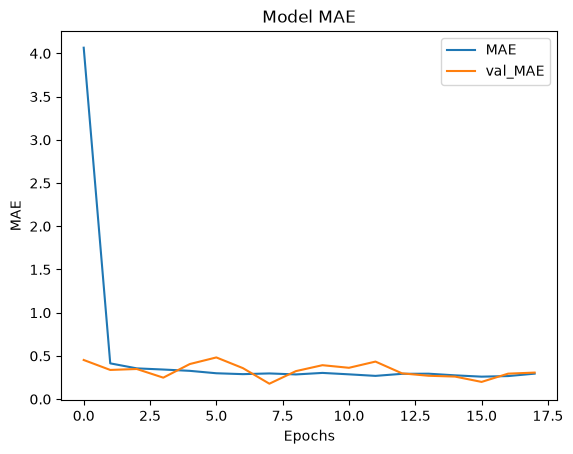

In [30]:

plt.figure()

plt.plot(history_dl.history['mean_absolute_error'], label='MAE')
plt.plot(history_dl.history['val_mean_absolute_error'], label='val_MAE')

plt.legend()
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')